In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from scipy import stats
# Turn on a setting to use Pandas more safely.
# We will discuss this setting ®later.
pd.set_option('mode.chained_assignment', 'raise')

# Also - set up plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

### Outline - 
### Permutation for slopes
- Solution to the permutation for slopes problem
### Analyzing count data
- Analyzing count data
  - Usually - Tables of data from different _categories_
    - categories: e.g. survived/died
    - first class/third class passengers
    - women/men
    - disease/no disease
- Question:  Does one category change the outcome in the other category
  - Does gender change the likelihood of disease?
  - Does SES change the incidence of depression?
- How can we answer these kinds of questions with our usual tools?
  - Permutation testing for count data

#### The answer for this is at the bottom of the wk8_2 class_working notebook

```
# we already have line_to_fit and real_slope from above.
# line_to_fit has columns for x, y and shuffle_x

# our usual 'recipe' for a loop
num_simulations = 1000
slope_values = np.zeros(num_simulations)
for i in np.arange(0,num_simulations):
    # do some stuff in the loop here, e.g. we will want to shuffle the x values
    line_to_fit["shuffle_x"] = np.random.permutation(line_to_fit["x"])
    

# plot the outcome
plt.hist(slope_values)
plt.axvline(real_slope, color="red")

# we haven't done anything yet, so the plot will just be a bar at zero
```

## Who survived on the titanic?
### Did it matter which class you were in?

<img src="Titanic.png" align = left>
<img src="Titanic_wreck.png" aligh = right>

### Read raw data
- Passenger list
  - Name, gender, age, relatives, fare
  - Who survived: survived = 1, died = 0

In [2]:
titanic_data = pd.read_csv("titanic.csv")
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [3]:
titanic_data["Pclass"].value_counts()

Pclass
3    487
1    216
2    184
Name: count, dtype: int64

### Making a summary table - who died/survived by passenger class
#### This is a 'cross tabulation table' or 'crosstabs table'
- Sometimes data that you download is already in summary format

In [4]:
survival_table = pd.crosstab(titanic_data["Survived"],titanic_data["Pclass"])
survival_table = survival_table.rename(columns={1:"first",2:"second",3:"third"})
survival_table

Pclass,first,second,third
Survived,,,
0,80,97,368
1,136,87,119


## tidying up

I just want to compare first and third class  

How do I drop second class?

In [5]:
# choose the columns you want to keep (by name)
survival_1_3 = survival_table[["first","third"]].copy()
survival_1_3

Pclass,first,third
Survived,,
0,80,368
1,136,119


In [6]:
# Another way - use 'drop' and list the columns you **don't** want
# choose the columns you want to drop
survival_1_3 = survival_table.drop(["second"],axis=1).copy() # brackets around 'second' in case you want to drop more than one column
survival_1_3

Pclass,first,third
Survived,,
0,80,368
1,136,119


In [7]:
# rename rows (remember that row names are
# called the 'index' of the data frame)
survival_1_3.rename(index={0:"died",1:"survived"},inplace=True)
survival_1_3

Pclass,first,third
Survived,,
died,80,368
survived,136,119


### Let's visualize that result (\*\*restart here\*\* for later exercise)

It will probably be clearest if we present percentages

In [8]:
# make a table of percentages

percent_survival=pd.DataFrame()
percent_survival["first"] = survival_1_3["first"]/np.sum(survival_1_3["first"])
percent_survival["third"] = survival_1_3["third"]/np.sum(survival_1_3["third"])
percent_survival

,first,third
Survived,,
died,0.37037,0.755647
survived,0.62963,0.244353


In [9]:
# break that down
survival_1_3["first"]

Survived
died         80
survived    136
Name: first, dtype: int64

```survival_1_3["first"]``` sends back all value in the 'first' column

In [12]:
# this sends back a single number - the sum of the values in the 'first' column
np.sum(survival_1_3["first"])

216

In [14]:
# get just the 'survived' values because that is
# what we will plot
survived_percentages=percent_survival.loc["survived"]

Text(0.5, 1.0, 'Class of Titanic survivors')

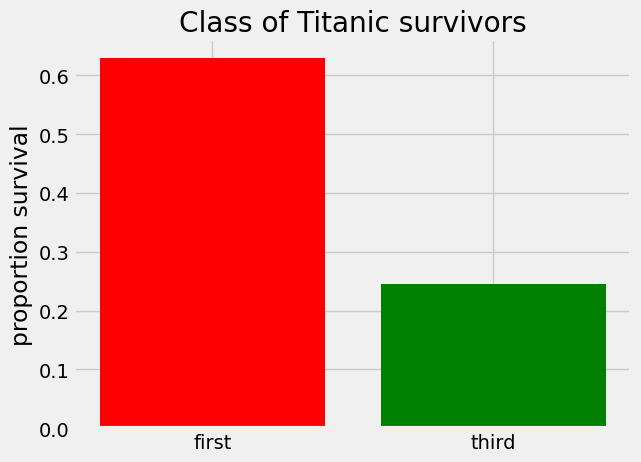

In [15]:
plt.bar(["first","third"],height=survived_percentages,color=["red","green"])
plt.ylabel("proportion survival")
plt.title("Class of Titanic survivors")

In [26]:
survived_percentages

first    0.629630
third    0.244353
Name: survived, dtype: float64

### Looks like first class passengers survived more often.  Was that difference real?
- How can we test that?
- Our usual tool - simulating a 'no difference' world/permutation test

### We started from the typical format of a cross-tabulation table

It would not be unusual to get data in this format
- From a summary dataset
- From a scientific article

## For our analysis, instead, we need the raw data -- What to do?

### How do we re-create that if we are starting from a summary table?

We want:
- 80 died/first
- 136 survived/first
- 368 died/third
- 119 survived/third

### Break that down

We want:
- 80 + 136 = 216 first class passengers
    - 80 died
    - 136 survived
- 368 + 119 = 487 third class passengers
    - 368 died
    - 119 survived
    
### Plan:
 - Make an array for 'class' - use the np.repeat function
   - 216 'first'
   - 487 'third'
 - Make a array for 'survived' and 'died' - use the np.repeat function again
   - **CAREFUL** We need died/survived **_within_** each class
   - 80/136 'died'/'survived'
   - 368/119 'died'/'survived'
 - Put arrays into a dataframe

In [27]:
# why do I get an error here?
# hint: Look at the colours

class = np.repeat(['first','third'],[np.sum(survival_1_3["first"]), np.sum(survival_1_3["third"])])

SyntaxError: invalid syntax (4291747209.py, line 4)

### 'class' is a python keyword (notice the color change) -- we can't use that

Also called a 'reserved word'

In [27]:
cabin_class = np.repeat(['first','third'], # values to repeate
                        [
                         np.sum(survival_1_3["first"]), # number of times to repeat
                         np.sum(survival_1_3["third"])
                        ])
# `np.sum(survival_1_3["first"])` sums the number of passengers in the "first" column of our summary table
# `np.sum(survival_1_3["third"])]` sums the number of passengers in the "third" column of our summary table

# print out the first and last five values in the array
cabin_class[[0,1,2,3,4,-5,-4,-3,-2,-1]]

array(['first', 'first', 'first', 'first', 'first', 'third', 'third',
       'third', 'third', 'third'], dtype='<U5')

In [23]:
first_third_counts = np.concatenate([survival_1_3["first"],survival_1_3["third"]])
# Now we want 'died', 'survived'  for first class and 'died', 'survived' for third class so we can
# Use repeat to create the died/survived data.
#
# Notice that we can't have just died/survived, because that won't line up with our first/third column
# We need died first, survived first, died third, survived third

In [25]:
# check the result -- we have saved the counts for
# first died/survived and third died/survived
first_third_counts

array([ 80, 136, 368, 119])

In [26]:
survived = np.repeat([0,1,0,1], # values to repeat
                     first_third_counts # number of times to repeat them
                    )
# we will make 0 = 'died' and 1 = 'survived'

# Put our count data into a new data frame and check...
# there were 80 first class survivors, so died/survived should change after row 79
my_titanic=pd.DataFrame()
my_titanic['class']=cabin_class
my_titanic['died/survived']=survived
print(my_titanic[75:85])
print(my_titanic[210:220])

    class  died/survived
75  first              0
76  first              0
77  first              0
78  first              0
79  first              0
80  first              1
81  first              1
82  first              1
83  first              1
84  first              1
     class  died/survived
210  first              1
211  first              1
212  first              1
213  first              1
214  first              1
215  first              1
216  third              0
217  third              0
218  third              0
219  third              0


In [31]:
# you can also do the died/survived column in two steps
first_survival = np.repeat([0,1],[80,136])
third_survival = np.repeat([0,1],[368,119])
survived = np.concatenate((first_survival, third_survival))

my_titanic=pd.DataFrame()
my_titanic['class']=cabin_class
my_titanic['died/survived']=survived
print(my_titanic[75:85])
print(my_titanic[210:220])

    class  died/survived
75  first              0
76  first              0
77  first              0
78  first              0
79  first              0
80  first              1
81  first              1
82  first              1
83  first              1
84  first              1
     class  died/survived
210  first              1
211  first              1
212  first              1
213  first              1
214  first              1
215  first              1
216  third              0
217  third              0
218  third              0
219  third              0


### Check that we've done this correctly - rebuild the table from the raw data
- Check that we get the same summary table back

In [32]:
my_titanic.value_counts("class")

class
third    487
first    216
Name: count, dtype: int64

In [33]:
my_titanic.value_counts("died/survived")

died/survived
0    448
1    255
Name: count, dtype: int64

In [34]:
pd.crosstab(my_titanic["died/survived"],my_titanic["class"])

class,first,third
died/survived,,
0,80,368
1,136,119


### OK, looks good...

### In our previous simulations/permutations we always need a critical value from the simulated world to compare to the real world.  What is our critical value this time?
- Think of our question;  Did survival differ in first and third class?
- What single value could we use?

### What one value can we use to capture whether survival differed?

- What about what we plotted above? - get % survival for each class
- Take the difference

### Analysis plan

Our usual recipe adapted for this case:

- Get the critical value from the real world - the difference in % survived for the classes
- Repeat our simulated world lots of times (shuffling data randomly/permutation),
- Calculate and save the critical value each time
- Plot the distribution of simulated values
- See if the real world value is common/rare among the simulated world values

You should feel like you've seen this many times before
</p>

#### Decisions to make:
- What should we shuffle?
- What will our critical value be?

### Calculate the critical value - (% survived first class - % survived third class)

In [ ]:
# Write a function to calculate the critical value

# percent_survival_difference
# This function calculates the difference in survival (0 = died, 1=survived)
# for two passenger classes ('first' and 'third')
# The arguments are:
#     pclass - an array with class labels ('first' or 'third')
#     survived - an array with 0/1 for died/survived
# The return value is the difference between first class survival and third class survival %

def percent_survival_difference(pclass,survived):
    # sum survival values for first class passengers and divide by the number of first class passengers
    survived_first_percentage = np.sum(survived[pclass == "first"])/len(survived[pclass == "first"])
    # sum survival values for third class passengers and divide by the number of third class passengers
    survived_third_percentage = np.sum(survived[pclass == "third"])/len(survived[pclass == "third"])
    percentage_difference = survived_first_percentage - survived_third_percentage
    return(percentage_difference)

In [ ]:
# try the percent_survival_difference on the real world data to get the real world critical value

real_survival_difference = percent_survival_difference(my_titanic['class'],my_titanic['died/survived'])
real_survival_difference

### Let's check that

Here is the table from above:

In [ ]:
percent_survival

In [ ]:
0.62963 - 0.244353

### Look's good

### What should we shuffle?
- We can shuffle first/third so who died in each class is randomized
  - If class doesn't matter, nothing should change.  The simulated and real values should be similar.
- Actually we can shuffle either died/survived or class.  There are only two, so shuffling either one re-pairs first/third and died/survived values. That is the critical thing you have to do
<br>

- In the 'no-difference' world, whether you die or survive does not depend on class
  - die/survive is randomly assigned to class
- In the simulated world if 40% of people survived overall (both classes together), about 40% will survive in each class
  - That is what shuffling does (distributes died/survived evenly over both classes)
- The real world might have many more people who survived in one class than the other

## Notice that the shuffled world doesn't have to be 50/50 died/survived
- If 80% of **all** passengers survived in the real world, in a shuffled world
  - on average, 80% of first class passengers will be paired with 'survived'
  - on average, 80% of third class passengers will be paired with 'survived'
- The percentage is the same for each class
- But it doesn't have to be 50%

### Notice how the unshuffled world could be different - Here is a possible real world

```
       died   survived
first:   1     99      total = 100 - 99% survived in first class
third:  39     61      total = 100 - 61% survived in third class (first and third are different)
      -----------
        40    160
        20%   80% (overall)
```

### A shuffled world (for comparison) - VERY DIFFERENT!

```
       died   survived
first:  20     80     total = 100 - 80% survived in first class
third:  20     80     total = 100 - 80% survived in third class (no difference between classes)
      -----------
        40    160
        20%   80% (overall)
```

The shuffled world won't look exactly the same each time - each shuffle will be slightly different

### Start of our simulated word recipe -- same as always: a place to store critical values; a loop

In [28]:
# The outline - our loop
num_simulations=10
sim_result = np.zeros(num_simulations)
for i in np.arange(0,num_simulations):
    # simulate world here (shuffle)
    # get critical value here
    # store critical value in sim_result[i]

    # gives an error because we haven't finished writing our loop yet

IndentationError: expected an indented block (842481192.py, line 9)

### The full simulated world

In [26]:
# The full loop - 
num_simulations=1000
sim_result = np.zeros(num_simulations)
for i in np.arange(0,num_simulations):
    # shuffle values
    shuffled_class = np.random.permutation(my_titanic['class'])
    
    # calculate the survival difference
    sim_survival_diff = percent_survival_difference(my_titanic['class'],shuffled_class)

    # save the critical difference
    sim_result[i] = sim_survival_diff
    
# Calculate a p-value:  Is the real result rare or common in the 'no difference' (shuffled) world?
# How often does a value >= real_survival_different occur in the 'no difference' world?
# Is the real value rare or common in the 'no difference' world?
num_occurences = np.count_nonzero(sim_result >= real_survival_difference)
p_value = num_occurences / num_simulations
print("A percent difference as big as on the titanic occured ",num_occurences)
print("   out of ",num_simulations," times in a world where class doesn't matter")
print("That has a probability of ",p_value)

A percent difference as big as on the titanic occured  0
   out of  1000  times in a world where class doesn't matter
That has a probability of  0.0


### Let's visualize that...

Text(0, 200, 'no-difference world')

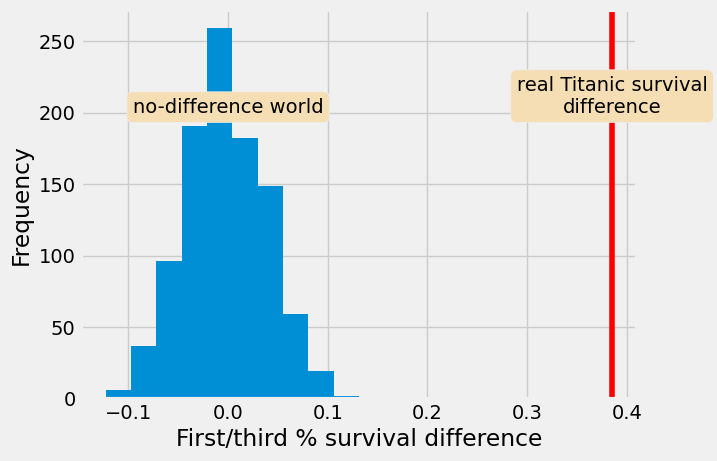

In [29]:
plt.hist(sim_result)
plt.axvline(real_survival_difference,color="red")
plt.xlabel("First/third % survival difference")
plt.ylabel("Frequency")
props = dict(boxstyle='round', facecolor='wheat')
plt.text(real_survival_difference,200,"real Titanic survival\ndifference",horizontalalignment="center",bbox=props)
plt.text(0,200,"no-difference world",horizontalalignment="center",bbox=props)

### The conventional statistical test would be chi-square

In [30]:
# we would use this table:

survival_1_3

Pclass,first,third
Survived,,
died,80,368
survived,136,119


In [31]:
stat, p, dof, expected = stats.chi2_contingency(survival_1_3)
print("Chi-square: ",np.round(stat,2)," p-value: ",p," df: ",dof)
print("Expected values:\n",expected)

Chi-square:  94.43  p-value:  2.5423203398081366e-22  df:  1
Expected values:
 [[137.65007112 310.34992888]
 [ 78.34992888 176.65007112]]


#### Notice that the p-value from the chi-square test is also very small

0.0000000000000000000000254

This value is essentially zero.  We would have to run **loads** of simulations to estimate a value this small.

In [14]:
survival_1_3

Pclass,first,third
Survived,,
died,80,368
survived,136,119


### Exercise: Try a different world -- make sure you understand how to interpret this result
#### (run the cell below here and then go back to \*\* restart here \*\* and run the cells after that point to try with these data)

In [46]:
survival_1_3["first"] = [168, 48]
survival_1_3["third"] = [400, 87]
survival_1_3

Pclass,first,third
Survived,,
died,168,400
survived,48,87
